## Simran Amesar

## Matriculation number - 100007050

In [83]:
texts = [
    "This phone is excellent",
    "Amazing battery life",
    "Very fast performance",
    "Camera quality is great",
    "I love this laptop",
    "Terrible customer service",
    "Battery drains quickly",
    "Very slow device",
    "Worst phone ever",
    "I hate this product",
    "I like this product but it's not the best"
]

In [84]:
# 1 = Positive
# 0 = Negative
# 2 = Neutral

labels = [1,1,1,1,1,0,0,0,0,0,2]

In [85]:
import numpy as np

from gensim.models import Word2Vec

In [86]:
tokenized_texts = [
    text.lower().split()
    for text in texts
]

In [87]:
print(tokenized_texts)

[['this', 'phone', 'is', 'excellent'], ['amazing', 'battery', 'life'], ['very', 'fast', 'performance'], ['camera', 'quality', 'is', 'great'], ['i', 'love', 'this', 'laptop'], ['terrible', 'customer', 'service'], ['battery', 'drains', 'quickly'], ['very', 'slow', 'device'], ['worst', 'phone', 'ever'], ['i', 'hate', 'this', 'product'], ['i', 'like', 'this', 'product', 'but', "it's", 'not', 'the', 'best']]


In [88]:
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    sg = 1
)

In [89]:
print(w2v_model.wv.index_to_key)

['this', 'i', 'product', 'very', 'battery', 'is', 'phone', 'best', 'the', 'not', "it's", 'but', 'like', 'hate', 'ever', 'worst', 'device', 'slow', 'quickly', 'drains', 'service', 'customer', 'terrible', 'laptop', 'love', 'great', 'quality', 'camera', 'performance', 'fast', 'life', 'amazing', 'excellent']


In [90]:
print(w2v_model.wv['excellent'])

[ 0.00260033 -0.01960861  0.00917553 -0.00107645  0.01266419  0.00356695
 -0.0062596   0.01551995  0.00310933  0.00011042 -0.00922591 -0.01690705
 -0.01553366  0.01734102 -0.01784992  0.01806943 -0.01856204 -0.00055351
 -0.00381409 -0.01786229  0.01726012  0.01355563  0.00603888  0.00966691
  0.00022438  0.01884936  0.01404257 -0.01970745 -0.00886644 -0.00258022
  0.00609545 -0.0086479   0.00289833 -0.0156918   0.00555615  0.00940538
  0.00987463 -0.0063514  -0.01685408 -0.01844124 -0.0014458  -0.01465493
 -0.01362993  0.01224001  0.01434461  0.00423484 -0.0157988  -0.01139798
  0.01610369  0.00784169]


In [91]:
print(
    w2v_model.wv.most_similar('excellent')
)

[('worst', 0.3173593282699585), ('this', 0.2406546175479889), ('the', 0.21870222687721252), ('customer', 0.2177131026983261), ('like', 0.18451760709285736), ('life', 0.1783401072025299), ('ever', 0.17044849693775177), ('performance', 0.13190807402133942), ('great', 0.12943966686725616), ('slow', 0.11862964183092117)]


In [92]:
def sentence_vector(sentence, model):

    words = sentence.lower().split()
    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [93]:
X = np.array([
    sentence_vector(text, w2v_model)
    for text in texts
])

In [94]:
print(X.shape)

(11, 50)


In [95]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense


In [96]:
model = Sequential() 
model.add(Dense(8, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(3, activation='softmax'))  # 3 output neurons: Negative, Positive, Neutral

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X,
    np.array(labels),
    epochs=300,
    verbose=1
)


/Users/chaahatamesar/Desktop/NLP/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435 (1.70 KB)

 Trainable params: 435 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2727 - loss: 1.0971
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3636 - loss: 1.0963
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3636 - loss: 1.0954
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3636 - loss: 1.0946
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4545 - loss: 1.0939
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5455 - loss: 1.0931
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5455 - loss: 1.0923
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5455 - loss: 1.0915
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5455 - loss: 1.0907
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5455 - loss: 1.0900
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6364 - loss: 1.0893
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6364 - l

In [97]:
loss, accuracy = model.evaluate(X, np.array(labels))

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8182 - loss: 0.8700
Accuracy: 0.8181818127632141


In [103]:
test_sentence = "Amazing performance and excellent battery"

test_vector = sentence_vector(
    test_sentence,
    w2v_model
)

test_vector = test_vector.reshape(1, -1)

prediction = model.predict(test_vector)

print(prediction)

predicted_class = np.argmax(prediction[0])

if predicted_class == 1:
    print("Positive Review")
elif predicted_class == 0:
    print("Negative Review")
else:
    print("Neutral Review")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[0.4235371  0.46240595 0.11405699]]
Positive Review


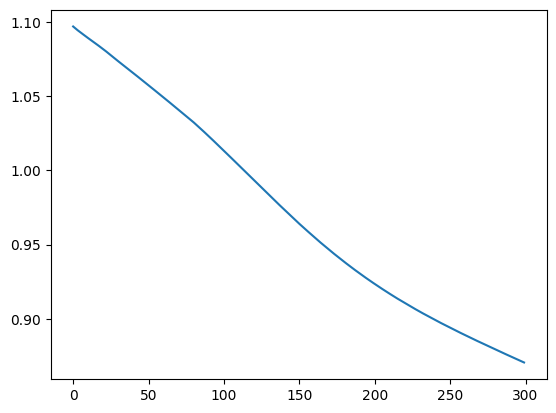

In [99]:
import matplotlib.pyplot as plt
# Training loss
plt.plot(history.history['loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


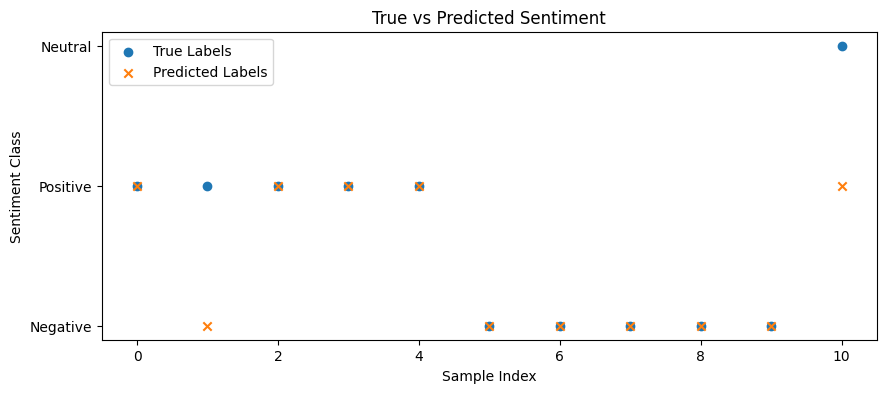

In [100]:
import matplotlib.pyplot as plt

raw_predictions = model.predict(X)
predicted_classes = np.argmax(raw_predictions, axis=1)

label_names = {0: "Negative", 1: "Positive", 2: "Neutral"}

plt.figure(figsize=(10, 4))
plt.scatter(range(len(labels)), labels, label="True Labels", marker="o")
plt.scatter(range(len(predicted_classes)), predicted_classes, label="Predicted Labels", marker="x")
plt.yticks([0, 1, 2], ["Negative", "Positive", "Neutral"])
plt.xlabel("Sample Index")
plt.ylabel("Sentiment Class")
plt.title("True vs Predicted Sentiment")
plt.legend()
plt.show()
